# CMPE 260 Meta Learning Project

## RL^2
-Created by OpenAI in 2016

Train an RNN over a distibution of tasks, using 'slow' RL to update weights which allows for a 'fast' learning capability on inference time.

In [ ]:
!pip install "stable-baselines3>=2.3.0" sb3-contrib gymnasium numpy torch
!pip install git+https://github.com/Farama-Foundation/Metaworld.git@master


MetaWorldEnv changes the behavior where the environment ends at the end of an episode or task. It will run K episodes back to back. It resets underlying environment without reporting back that its done to the agent.

This is the key for Meta-RL and RL squared as the hidden state should only be reset at the start of the meta-episode. We want the agent to maintain memory and carry it across tasks.

This is the the outer-loop and meta-episode across trials.

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class MetaWorldEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, sampler_function, K=3, max_episode_steps=150, seed=42, reward_scale=1.0):
        super().__init__()
        self.sampler_function=sampler_function
        self.K = K
        self.max_episode_steps=max_episode_steps
        self.reward_scale=reward_scale
        self._rng = np.random.default_rng(seed)
        random.seed(seed)

        proto, _=self.sampler_function() # prototype env to define spaces
        self.observation_space = proto.observation_space
        self.action_space = proto.action_space
        proto.close()

        low = np.concatenate([
            self.observation_space.low.astype(np.float32),
            self.action_space.low.astype(np.float32),
            np.array([-np.inf], dtype=np.float32),
            np.array([0.0], dtype=np.float32),
        ])
        high = np.concatenate([
            self.observation_space.high.astype(np.float32),
            self.action_space.high.astype(np.float32),
            np.array([np.inf], dtype=np.float32),
            np.array([1.0], dtype=np.float32),
        ])
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = self.action_space

        self.env = proto
        self.inner_ep = 0
        self.steps = 0
        self.prev_action = np.zeros(self.action_space.shape, dtype=np.float32)
        self.prev_reward = 0.0
        self.prev_done = 0.0

    def _augment(self, obs: np.ndarray) -> np.ndarray:
        return np.concatenate([
            obs.astype(np.float32, copy=False),
            self.prev_action,
            np.array([self.prev_reward], dtype=np.float32),
            np.array([self.prev_done], dtype=np.float32),
        ]).astype(np.float32, copy=False)


    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(seed)
            random.seed(seed)

        if self.env is not None:
            self.env.close()
        self.env, _ = self.sampler_function()

        self.current_task_name=self.env.__class__.__name__

        self.inner_ep = 0
        self.steps = 0
        self.prev_action[:] = 0.0
        self.prev_reward = 0.0
        self.prev_done = 0.0

        obs, info = self.env.reset(seed=seed)
        info = dict(info)
        info["trial_done"] = False
        info["trial_idx"] = 0
        return self._augment(obs), info

    def step(self, action):
        obs, r, terminated, truncated, info = self.env.step(action)
        self.steps+=1
        done = terminated or truncated or (self.steps >= self.max_episode_steps)
        trial_done=False
        outer_done=False
        if done:
            self.inner_ep+=1
            trial_done=True
            self.steps=0

            if self.inner_ep < self.K:
               obs, _=self.env.reset()
               outer_done=False
            else:
              outer_done=True

        self.prev_action = np.asarray(action, dtype=np.float32)
        self.prev_reward = float(r) * self.reward_scale
        self.prev_done = 1.0 if trial_done else 0.0
        info = dict(info)
        info["trial_done"] = trial_done
        info["trial_idx"] = self.inner_ep - 1 if trial_done else self.inner_ep
        info["env_name"]=getattr(self, "current_task_name", "unknown")
        return self._augment(obs), r, outer_done, False, info


    def close(self):
        if self.env is not None:
            self.env.close()
            self.env = None
        super().close()

In [ ]:
import metaworld
import random
from typing import List, Dict, Tuple
import gymnasium as gym
import numpy as np
from gymnasium import spaces
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

def build_ml10(seed=123):
  rng=np.random.default_rng(seed)
  ml10=metaworld.ML10()

  train_classes=ml10.train_classes
  named_sort_train_tasks: Dict[str, List]={}
  for task in ml10.train_tasks:
    named_sort_train_tasks.setdefault(task.env_name, []).append(task)

  names=list(named_sort_train_tasks.keys())
  print(names)

  def sample():
    name=names[rng.integers(0, len(names))]
    classes=train_classes[name]
    env=classes()
    task=random.choice(named_sort_train_tasks[name])
    env.set_task(task)
    return env, task

  return sample

In [ ]:
from gymnasium.wrappers import TimeLimit
from stable_baselines3.common.vec_env import VecNormalize
from sb3_contrib import RecurrentPPO

max_episode_steps=256
K = 3
N_ENVS = 8
SEED = 123
TOTAL_TIMESTEPS = 1_000_000

def make_vec_env(n_envs, seed, K, max_episode_steps):
    sampler_function=build_ml10(seed)
    def make_one(rank):
        def _init():
            e = MetaWorldEnv(sampler_function, K, max_episode_steps, reward_scale=1.0)
            e.reset(seed=seed + rank)
            return e
        return _init
    return VecNormalize(VecMonitor(DummyVecEnv([make_one(i) for i in range(n_envs)])), norm_obs=True, norm_reward=True, clip_obs=10.0)


In [ ]:
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
eval_env  = make_vec_env(1, SEED+10_000, K, max_episode_steps)
eval_env.training=False
eval_env.obs_rms = train_env.obs_rms

['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']
['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']


ABLATIONS:
- critic lstm [True/False]*
- shared lstm [True/False]*
- learning rate [1e-4, 3e-4]
- seeds *
- K inner trials [1, 3, 5] *

*=priority

### Ablation models

#### Critic & Shared_LSTM

In [ ]:
SEED = 123
K=3
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/critic"
TOTAL_TIMESTEPS=400_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model6 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=False,
        enable_critic_lstm=True,
        net_arch=[128, 128],
    ),
)
model6.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/critic/critic_enabled_rl2_ml10"
model6.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']


In [ ]:
SEED = 123
K=3
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/critic"
TOTAL_TIMESTEPS=400_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model7 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model7.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/critic/no_critic_shared_lstm_rl2_ml10"
model7.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']


#### Learning Rate

In [ ]:
SEED = 123
K=3
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/lr"
TOTAL_TIMESTEPS=300_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model4 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model4.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/lr/lr_3e4_rl2_ml10"
model4.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']


In [ ]:
SEED = 123
K=3
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/lr"
TOTAL_TIMESTEPS=300_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model5 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=1e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model5.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/lr/lr_1e4_rl2_ml10"
model5.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

['reach-v3', 'push-v3', 'pick-place-v3', 'door-open-v3', 'drawer-close-v3', 'button-press-topdown-v3', 'peg-insert-side-v3', 'window-open-v3', 'sweep-v3', 'basketball-v3']


#### K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SEED = 123
K=1
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K"
TOTAL_TIMESTEPS=400_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model1 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model1.learn(total_timesteps=TOTAL_TIMESTEPS)



In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K/k1_rl2_ml10"
model1.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

In [ ]:
SEED = 123
K=3
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K"
TOTAL_TIMESTEPS=400_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model2 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model2.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K/k3_rl2_ml10"
model2.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

In [ ]:
SEED = 123
K=5
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K"
TOTAL_TIMESTEPS=400_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model3 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)
model3.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K/k5_rl2_ml10"
model3.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

#### Seeds

In [ ]:
SEED = 1
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds"

TOTAL_TIMESTEPS=200_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=1,
    n_steps=256,
    batch_size=256,
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds/seed1_rl2_ml10_10epochs"
model.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

-----------------------------------------------------------------------------------

In [ ]:
SEED = 2
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds"
TOTAL_TIMESTEPS=200_000
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds/seed2_rl2_ml10"
model.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

--------------------------------------------------------------------------------------

In [ ]:
SEED = 3
TOTAL_TIMESTEPS=200_000
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds"
train_env = make_vec_env(N_ENVS, SEED, K, max_episode_steps)
model = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False,
        net_arch=[128, 128],
    ),
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds/seed3_rl2_ml10"
model.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### N-Shot Learning Eval During Training

In [ ]:
class MetaWorldEvalEnv(gym.Env):
    metadata = {"render_modes": []}
    def __init__(self, env_cls, task, K=1, max_episode_steps=150, reward_scale=1.0):
        super().__init__()
        self.env_cls=env_cls
        self.task=task
        self.K = K
        self.max_episode_steps=max_episode_steps
        self.reward_scale=reward_scale

        self.env=env_cls()
        self.env.set_task(task)

        low = np.concatenate([
            self.env.observation_space.low.astype(np.float32),
            self.env.action_space.low.astype(np.float32),
            np.array([-np.inf], dtype=np.float32),
            np.array([0.0], dtype=np.float32),
        ])
        high = np.concatenate([
            self.env.observation_space.high.astype(np.float32),
            self.env.action_space.high.astype(np.float32),
            np.array([np.inf], dtype=np.float32),
            np.array([1.0], dtype=np.float32),
        ])

        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = self.env.action_space

        self.inner_ep = 0
        self.steps = 0
        self.prev_action = np.zeros(self.action_space.shape, dtype=np.float32)
        self.prev_reward = 0.0
        self.prev_done = 0.0
        self.episode_rewards=[]
        self.episode_successes=[]
        self.current_ep_reward=0.0

    def _augment(self, obs: np.ndarray) -> np.ndarray:
        return np.concatenate([
            obs.astype(np.float32, copy=False),
            self.prev_action,
            np.array([self.prev_reward], dtype=np.float32),
            np.array([self.prev_done], dtype=np.float32),
        ]).astype(np.float32, copy=False)


    def reset(self, *, seed=None, options=None):
        self.inner_ep = 0
        self.steps = 0
        self.prev_action = np.zeros(self.action_space.shape, dtype=np.float32)
        self.prev_reward = 0.0
        self.prev_done = 0.0
        self.episode_rewards=[]
        self.episode_successes=[]
        self.current_ep_reward=0.0

        obs, info = self.env.reset(seed=seed)
        info = dict(info)
        info["trial_done"] = False
        info["trial_idx"] = 0
        return self._augment(obs), info

    def step(self, action):
        obs, r, terminated, truncated, info = self.env.step(action)
        self.steps+=1
        self.current_ep_reward+=r
        done = terminated or truncated or (self.steps >= self.max_episode_steps)
        trial_done=False
        outer_done=False
        if done:
            self.inner_ep+=1
            trial_done=True
            self.episode_rewards.append(self.current_ep_reward)
            self.episode_successes.append(info.get("success", False))

            self.steps=0
            self.current_ep_reward=0.0

            if self.inner_ep < self.K:
               obs, _=self.env.reset()
               outer_done=False
            else:
              outer_done=True

        self.prev_action = np.asarray(action, dtype=np.float32)
        self.prev_reward = float(r) * self.reward_scale
        self.prev_done = 1.0 if trial_done else 0.0

        info = dict(info)
        info["trial_done"] = trial_done
        info["trial_idx"] = self.inner_ep - 1 if trial_done else self.inner_ep
        info["env_name"]=getattr(self, "current_task_name", "unknown")
        return self._augment(obs), r, outer_done, False, info


    def close(self):
        if self.env is not None:
            self.env.close()
            self.env = None
        super().close()

In [ ]:
from gymnasium import spaces
from collections import defaultdict
from stable_baselines3.common.callbacks import BaseCallback
import json
import os
class MetaEvalCallback(BaseCallback):
    def __init__(self,ml10,eval_freq=25,n_tasks_per_class=3,k_shots=[0, 1, 3],max_ep_steps=150,log_path="/content/drive/Shared drives/CMPE260_group12/rl2_models",verbose=1,):
        super().__init__(verbose)
        self.ml10 = ml10
        self.eval_freq = eval_freq
        self.n_tasks_per_class = n_tasks_per_class
        self.k_shots = k_shots
        self.max_ep_steps = max_ep_steps
        self.log_path = log_path
        self.best_reward = -np.inf
        self.eval_history = []
        self.rollout_count = 0

    def _on_rollout_end(self):
        self.rollout_count += 1
        if self.rollout_count % self.eval_freq == 0:
            self._run_evaluation()

    def _run_evaluation(self):
        total_steps = self.num_timesteps
        if self.verbose:
            print(f"\n{'#'*60}")
            print(f"# META-EVALUATION at step {total_steps} (rollout {self.rollout_count})")
            print(f"{'#'*60}")


        results = evaluate_meta_policy(model=self.model,ml10=self.ml10,n_tasks_per_class=self.n_tasks_per_class,k_shots=self.k_shots, max_ep_steps=self.max_ep_steps,)

        summary = print_eval_results(results)

        for k, metrics in summary.items():
            self.logger.record(f"eval/{k}shot_reward", metrics["reward"])
            self.logger.record(f"eval/{k}shot_success_rate", metrics["success_rate"])

        check_k = 1 if 1 in summary else min(self.k_shots)
        current_reward = summary[check_k]["reward"]

        if current_reward > self.best_reward:
            self.best_reward = current_reward
            if self.log_path:
                os.makedirs(self.log_path, exist_ok=True)
                save_path = os.path.join(self.log_path, "best_model")
                self.model.save(save_path)
                if self.verbose:
                    print(f"\n  *** New best model! {check_k}-shot reward: {self.best_reward:.2f} ***")

        self.eval_history.append({"step": total_steps,"rollout": self.rollout_count,"summary": summary,})

        if self.log_path:
            os.makedirs(self.log_path, exist_ok=True)
            with open(os.path.join(self.log_path, "eval_history.json"), "w") as f:
                json.dump(self.eval_history, f, indent=2)

    def _on_step(self):
        return True

    def _on_training_end(self):
        if self.verbose:
            print(f"\n{'='*60}")
            print("FINAL EVALUATION")
            print(f"{'='*60}")

        final_results = evaluate_meta_policy(
            model=self.model,ml10=self.ml10,n_tasks_per_class=5,k_shots=self.k_shots,max_ep_steps=self.max_ep_steps,)

        print_eval_results(final_results)

In [ ]:
def evaluate_meta_policy(model, ml10, n_tasks_per_class=3, k_shots=[0, 1, 3], max_ep_steps=150):
    results = {k: defaultdict(list) for k in k_shots}
    for env_name, env_cls in ml10.test_classes.items():
        print(f"  Evaluating on {env_name}...")

        test_tasks = [t for t in ml10.test_tasks if t.env_name == env_name]
        n_to_sample = min(n_tasks_per_class, len(test_tasks))

        if n_to_sample == 0:
            print(f"    Warning: No tasks found for {env_name}, skipping...")
            continue
        sampled_tasks = random.sample(test_tasks, n_to_sample)
        for task in sampled_tasks:
            for k in k_shots:
                print("episode_start at step:", total_steps, "->", bool(episode_start[0]))
                total_eps = k + 1
                eval_env = DummyVecEnv([lambda: MetaWorldEvalEnv(env_cls=env_cls, task=task, K=total_eps, max_episode_steps=max_ep_steps)])

                eval_env = VecNormalize.load("vecnormalize.pkl", eval_env)
                eval_env.training = False
                eval_env.norm_reward = False
                obs, _ = eval_env.reset()
                lstm_states = None
                episode_start = np.array([True])

                max_total_steps = total_eps * max_ep_steps + 100
                total_steps = 0

                while total_steps < max_total_steps:
                    action, lstm_states = model.predict(
                        obs,
                        state=lstm_states,
                        episode_start=episode_start,
                        deterministic=False,
                    )

                    obs, reward, terminated, truncated, info = eval_env.step(action)
                    done=terminated or truncated
                    total_steps += 1
                    episode_start = np.array([total_steps == 0])
                if terminated and total_steps >= max_total_steps:
                    break

                if len(eval_env.episode_rewards) > 0:
                    results[k][env_name].append({
                        "reward": eval_env.episode_rewards[-1],
                        "success": float(eval_env.episode_successes[-1]),
                    })
                else:
                    print(f"    Warning: No episodes completed for {env_name} with k={k}")
                    results[k][env_name].append({
                        "reward": 0.0,
                        "success": 0.0,
                    })

                eval_env.close()

    return results

def print_eval_results(results):
    summary = {}
    for k in sorted(results.keys()):
        print(f"\n{'='*60}")
        print(f"  {k}-SHOT EVALUATION")
        print(f"{'='*60}")

        all_rewards = []
        all_successes = []

        for env_name, trials in sorted(results[k].items()):
            rewards = [t["reward"] for t in trials]
            successes = [t["success"] for t in trials]
            mean_r = np.mean(rewards)
            std_r = np.std(rewards)
            success_rate = np.mean(successes) * 100

            print(f"{env_name:40s} | R: {mean_r:7.2f} ± {std_r:5.2f} | SR: {success_rate:5.1f}%")
            all_rewards.extend(rewards)
            all_successes.extend(successes)

        overall_reward = np.mean(all_rewards)
        overall_std = np.std(all_rewards)
        overall_success = np.mean(all_successes) * 100

        print(f"{'-'*60}")
        print(f"{'OVERALL':40s} | R: {overall_reward:7.2f} ± {overall_std:5.2f} | SR: {overall_success:5.1f}%")

        summary[k] = {"reward": overall_reward,"reward_std": overall_std,"success_rate": overall_success,}

    return summary

### Fixed Parameter Model for Assessment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_with_k_shot"

model = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=1,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005, #ABLATE THIS
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=4,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False, #ABLATION THIS
        net_arch=[128, 128],
    ),
)

ml10 = metaworld.ML10(seed=123)
eval_callback=MetaEvalCallback(
    ml10=ml10,
    eval_freq=25,
    n_tasks_per_class=3,
    k_shots=[0, 1, 3],
    log_path="/content/drive/Shared drives/CMPE260_group12/rl2_models",
    verbose=1,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)

In [ ]:
ml10 = metaworld.ML10(seed=123)
eval_callback=MetaEvalCallback(
    ml10=ml10,
    eval_freq=25,
    n_tasks_per_class=3,
    k_shots=[0, 1, 3],
    log_path="/content/drive/Shared drives/CMPE260_group12/rl2_models",
    verbose=1,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)

In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_with_k_shot"
model.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

In [ ]:
tensor_board_dir="/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_with_k_shot/8epochs"

model9 = RecurrentPPO(
    "MlpLstmPolicy",
    train_env,
    verbose=0,
    n_steps=256,
    batch_size=256,   # must divide n_steps * n_envs
    learning_rate=3e-4,
    ent_coef=0.005, #ABLATE THIS
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    n_epochs=8,
    tensorboard_log=tensor_board_dir,
    policy_kwargs=dict(
        lstm_hidden_size=128,
        n_lstm_layers=1,
        shared_lstm=True,
        enable_critic_lstm=False, #ABLATION THIS
        net_arch=[128, 128],
    ),
)

ml10 = metaworld.ML10(seed=123)
eval_callback=MetaEvalCallback(
    ml10=ml10,
    eval_freq=10,
    n_tasks_per_class=3,
    k_shots=[0, 1, 3],
    log_path="/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_with_k_shot/8epochs/freq_updates",
    verbose=1,
)

model9.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)



############################################################
# META-EVALUATION at step 20480 (rollout 10)
############################################################
  Evaluating on drawer-open-v3...
  Evaluating on door-close-v3...
  Evaluating on shelf-place-v3...
  Evaluating on sweep-into-v3...
  Evaluating on lever-pull-v3...

  0-SHOT EVALUATION
door-close-v3                            | R:   18.48 ±  4.70 | SR:   0.0%
drawer-open-v3                           | R:  141.18 ±  5.17 | SR:   0.0%
lever-pull-v3                            | R:  133.16 ± 30.10 | SR:   0.0%
shelf-place-v3                           | R:    0.00 ±  0.00 | SR:   0.0%
sweep-into-v3                            | R:    7.46 ±  2.78 | SR:   0.0%
------------------------------------------------------------
OVERALL                                  | R:   60.06 ± 64.79 | SR:   0.0%

  1-SHOT EVALUATION
door-close-v3                            | R:   18.44 ±  4.70 | SR:   0.0%
drawer-open-v3                       

KeyboardInterrupt: 

In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_with_k_shot/8epochs/freq_updates"
model9.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

In [ ]:
%load_ext tensorboard
%tensorboard --logdir "/content/drive/Shared drives/CMPE260_group12/rl2_models/tensorboard/RecurrentPPO_2"


In [ ]:
from tensorboard.backend.event_processing import event_accumulator
log_dir =tensor_board_dir+'/tensorboard/RecurrentPPO_2'
ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()
print(ea.Tags())

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_rl2_ml10_10epochs"
model.save(save_path)
train_env.save(save_path + "_vecnorm.pkl")

## Eval

In [ ]:
def test_build_ml10(seed=123):
  rng=np.random.default_rng(seed)
  ml10=metaworld.ML10()

  test_classes=ml10.test_classes
  test_tasks=ml10.test_tasks

  named_sort_test_tasks = {}
  for task in test_tasks:
    named_sort_test_tasks.setdefault(task.env_name, []).append(task)

  names=list(named_sort_test_tasks.keys())
  print(names)

  def sample():
    name=rng.choice(names)
    EnvClass=test_classes[name]
    env=EnvClass()
    task=random.choice(named_sort_test_tasks[name])
    env.set_task(task)
    return env, task

  return sample

def test_make_vec_env(n_envs, seed, K, max_episode_steps):
    sampler_function=test_build_ml10(seed)
    def make_one(rank):
        def _init():
            e = MetaWorldEnv(sampler_function, K, max_episode_steps, reward_scale=1.0)
            e.reset(seed=seed + rank)
            return e
        return _init
    return VecMonitor(DummyVecEnv([make_one(i) for i in range(n_envs)]))

In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/fixed_params_rl2_ml10_10epochs"
eval_env = VecNormalize.load(save_path + "_vecnorm.pkl", test_make_vec_env(1, SEED+10_000, K, max_episode_steps))
eval_env.training = False
eval_env.norm_reward = False

model = RecurrentPPO.load(save_path + ".zip", env=eval_env)

In [ ]:
lstm_states=None
meta_rewards=[]
n_eval_episodes=10
inner_rewards=np.zeros((n_eval_episodes, K))

for ep in range(n_eval_episodes):
  obs=eval_env.reset()
  done=False
  total_reward = 0.0
  lstm_states=None
  step_rewards=[]
  trial_index=0
  info=[{}]

  while not done:
    episode_start=np.array([info[0].get("trial_done", False)], dtype=bool)
    action, lstm_states = model.predict(obs, state=lstm_states, episode_start=episode_start, deterministic=True)
    obs, reward, done, info = eval_env.step(action)
    step_rewards.append(reward[0])
    total_reward += reward[0]

    if info[0].get("trial_done", False):
      inner_rewards[ep, trial_index]=np.mean(step_rewards)
      step_rewards=[]
      trial_index+=1

  meta_rewards.append(total_reward)
  task_name = info[0].get("env_name", "?")
  print(f"Meta-episode {ep + 1} | Task: {task_name} | Total reward: {total_reward:.2f}")

print(f"\nMean reward over {n_eval_episodes} meta-episodes: "
      f"{np.mean(meta_rewards):.2f} ± {np.std(meta_rewards):.2f}")

Meta-episode 1 | Task: SawyerDoorCloseEnvV3 | Total reward: 14.64
Meta-episode 2 | Task: SawyerDoorCloseEnvV3 | Total reward: 12.68
Meta-episode 3 | Task: SawyerSweepIntoGoalEnvV3 | Total reward: 37.35
Meta-episode 4 | Task: SawyerShelfPlaceEnvV3 | Total reward: 0.00
Meta-episode 5 | Task: SawyerShelfPlaceEnvV3 | Total reward: 0.00
Meta-episode 6 | Task: SawyerDrawerOpenEnvV3 | Total reward: 505.04
Meta-episode 7 | Task: SawyerDoorCloseEnvV3 | Total reward: 14.60
Meta-episode 8 | Task: SawyerLeverPullEnvV3 | Total reward: 121.88
Meta-episode 9 | Task: SawyerDoorCloseEnvV3 | Total reward: 14.60
Meta-episode 10 | Task: SawyerShelfPlaceEnvV3 | Total reward: 0.00

Mean reward over 10 meta-episodes: 72.08 ± 148.38


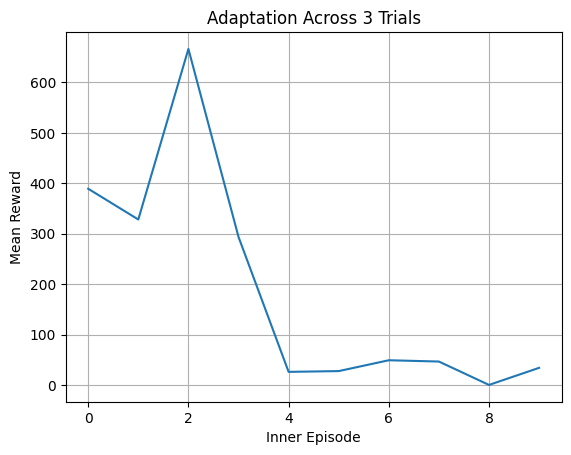

In [ ]:
import matplotlib.pyplot as plt
y=meta_rewards

plt.plot(range(0, n_eval_episodes), y)
plt.title(f"Rewards from Varying Tasks")
plt.xlabel("Meta Episode Number")
plt.ylabel("Reward from Task")
plt.grid(True)
plt.show()

## Eval (REAL)

In [ ]:
import torch
def run_one_epi(env, model, obs, count_success=True, lstm_state=None, reset_state=False):
  success=0
  total_reward=0.0
  task_name="meep"
  first_step=True
  done=False
  total_shot_steps=0

  while not done:
      episode_start = np.array([reset_state and first_step])
      a, lstm_state=model.predict(obs, state=lstm_state, episode_start=episode_start, deterministic=False)
      obs, r, dones, info = env.step(a)
      total_shot_steps+=1
      done=dones[0]
      total_reward+=r[0]
      episode_start=dones

      if "env_name" in info[0]:
        task_name=info[0]["env_name"]

      if count_success and info[0].get("success", 0.0) == 1.0:
        success=1

  return success, total_reward, task_name, obs, lstm_state, total_shot_steps


def run_k_shot(model,env, test_tasks, k_shot=0):
    successes=0
    rewards=[]
    obs=env.reset()
    shot_steps=[]
    lstm_state = None

    for k in range(k_shot-1):
      reset_state = (k == 0 and lstm_state is None)
      _, r, task_name, obs, lstm_state, steps=run_one_epi(env, model, obs, count_success=False, lstm_state=lstm_state)
      rewards.append(r)
      shot_steps.append(steps)
      #print(f"Task: {task_name} | Round {k}  | "f"Reward: {r:.2f} | ")

    success, r, task_name, obs, lstm_state, steps=run_one_epi(env, model, obs, count_success=True, lstm_state=lstm_state)
    print(f"| Final K_shot "f"Task: {task_name} | "f"Reward: {r:.2f} | ")
    rewards.append(r)
    shot_steps.append(steps)
    mean_reward=np.mean(rewards)
    if success==1:
      print(f"Task: {task_name} succeeded")
    print(f"Task: {task_name} | "f"Mean reward: {mean_reward:.2f} | "f"Success: {success}")
    #print(f"Steps per shot: {shot_steps}")
    return np.mean(success), rewards

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def make_env(task, K=1, max_episode_steps=256):
    def sampler():
        EnvClass = type(task.get_env()) if hasattr(task, "get_env") else ml10.test_classes[task.env_name]
        env = EnvClass()
        env.set_task(task)
        return env, task
    return MetaWorldEnv(sampler_function=sampler, K=K, max_episode_steps=max_episode_steps)

In [ ]:
ml10=metaworld.ML10()
drawer_task = [t for t in ml10.test_tasks if t.env_name == "drawer-open-v3"][0]
shelf_place= [t for t in ml10.test_tasks if t.env_name == "shelf-place-v3"][0]
door_close= [t for t in ml10.test_tasks if t.env_name == "door-close-v3"][0]
sweep_into= [t for t in ml10.test_tasks if t.env_name == "sweep-into-v3"][0]
lever_pull = [t for t in ml10.test_tasks if t.env_name == "lever-pull-v3"][0]

shelf_env = DummyVecEnv([lambda: make_env(shelf_place, K=K)])
drawer_env = DummyVecEnv([lambda: make_env(drawer_task, K=K)])
door_env = DummyVecEnv([lambda: make_env(door_close, K=K)])
door_env.training = False
door_env.norm_reward = False
sweep_env = DummyVecEnv([lambda: make_env(sweep_into, K=K)])
lever_env = DummyVecEnv([lambda: make_env(lever_pull, K=K)])

In [ ]:
import matplotlib.pyplot as plt

def plot(ablations_model_list, ablations_rewards_list, k, title="5-Shot on Door-Close"):
  for name, rewards in zip(ablations_model_list, ablations_rewards_list):
    plt.plot(np.arange(1, 6), rewards, label=name)
  plt.title(title)
  plt.xlabel("Meta Episode Number")
  plt.xticks(range(1, 6))
  plt.ylabel("Reward from Task")
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/"

K=3
max_episode_steps=256
door_env = DummyVecEnv([lambda: make_env(door_close, K=K)])
door_env.training = False
door_env.norm_reward = False

In [ ]:
fixed_param_model= RecurrentPPO.load(save_path +"fixed_params_rl2_ml10_10epochs" + ".zip", env=door_env)
critic_enabled_model= RecurrentPPO.load(save_path + "ablations/critic/critic_enabled_rl2_ml10"+ ".zip", env=door_env)
no_critic_model= RecurrentPPO.load(save_path +"ablations/critic/no_critic_shared_lstm_rl2_ml10"+ ".zip", env=door_env)
k1_model= RecurrentPPO.load(save_path + "/ablations/K/k1_rl2_ml10"+".zip", env=door_env)
k3_model= RecurrentPPO.load(save_path +"/ablations/K/k3_rl2_ml10"+ ".zip", env=door_env)
k5_model= RecurrentPPO.load(save_path + "/ablations/K/k5_rl2_ml10"+".zip", env=door_env)
lr1e4_model= RecurrentPPO.load(save_path +"/ablations/lr/lr_1e4_rl2_ml10"+ ".zip", env=door_env)
lr3e4_model= RecurrentPPO.load(save_path + "/ablations/lr/lr_3e4_rl2_ml10"+".zip", env=door_env)
seed1_model= RecurrentPPO.load(save_path + "/ablations/seeds/seed1_rl2_ml10_10epochs"+".zip", env=door_env)
seed2_model= RecurrentPPO.load(save_path + "/ablations/seeds/seed2_rl2_ml10"+".zip", env=door_env)
seed3_model= RecurrentPPO.load(save_path + "/ablations/seeds/seed3_rl2_ml10"+".zip", env=door_env)

In [ ]:
def run_test_task(models, env, task, k_shot):
  results_list=[]
  for model in models:
    successes, reward=run_k_shot(model, env, task, k_shot)
    print(reward)
    results_list.append(reward)
  return results_list

| Final K_shot Task: SawyerDoorCloseEnvV3 | Reward: 187.39 | 
Task: SawyerDoorCloseEnvV3 | Mean reward: 203.48 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(209.52185), np.float32(206.88908), np.float32(234.85677), np.float32(178.76723), np.float32(187.38661)]
| Final K_shot Task: SawyerDoorCloseEnvV3 | Reward: 1094.70 | 
Task: SawyerDoorCloseEnvV3 | Mean reward: 1978.53 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(2285.2798), np.float32(2109.8054), np.float32(2508.3823), np.float32(1894.468), np.float32(1094.6979)]
| Final K_shot Task: SawyerDoorCloseEnvV3 | Reward: 42.95 | 
Task: SawyerDoorCloseEnvV3 | Mean reward: 44.68 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(46.063904), np.float32(42.763515), np.float32(46.761364), np.float32(44.83936), np.float32(42.953773)]
| Final K_shot Task: SawyerDoorCloseEnvV3 | Reward: 78.79 | 
Task: SawyerDoorCloseEnvV3 | Mean reward: 66.54 | Success: 0
Steps per shot: [768, 768, 768, 76

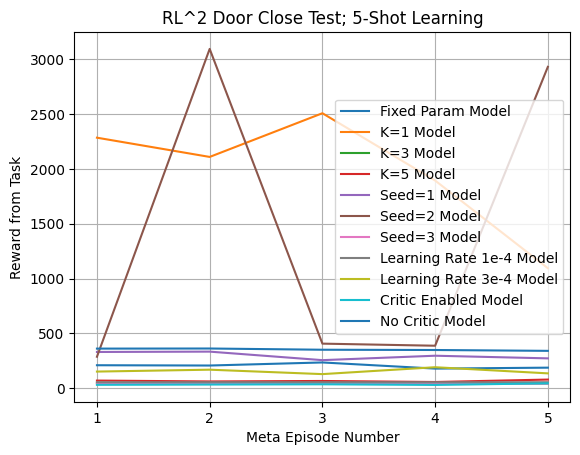

In [ ]:
results_model_list=[
    "Fixed Param Model",
    "K=1 Model",
    "K=3 Model",
    "K=5 Model",
    "Seed=1 Model",
    "Seed=2 Model",
    "Seed=3 Model",
    "Learning Rate 1e-4 Model",
    "Learning Rate 3e-4 Model",
    "Critic Enabled Model",
    "No Critic Model"
]

model_list=[
    fixed_param_model,
    k1_model,
    k3_model,
    k5_model,
    seed1_model,
    seed2_model,
    seed3_model,
    lr1e4_model,
    lr3e4_model,
    critic_enabled_model,
    no_critic_model
]

door_rewards_list=run_test_task(model_list, door_env, door_close, k_shot=5)
plot(results_model_list, door_rewards_list, k=5, title="RL^2 Door Close Test; 5-Shot Learning")

| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 80.77 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 73.66 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 106.86 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 103.55 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 15.33 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 15.04 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 23.12 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 23.48 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 20.07 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 18.28 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 81.02 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 73.23 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 43.79 | 
Task: SawyerSweepIntoGoalEnvV3 | Mean reward: 35.63 | Success: 0
| Final K_shot Task: SawyerSweepIntoGoalEnvV3 | Reward: 12.67 | 
Task: SawyerSweepIntoGo

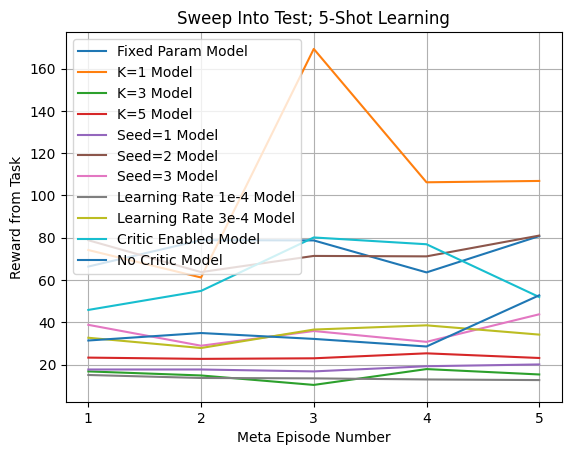

In [ ]:
sweep_rewards_list=run_test_task(model_list, sweep_env, sweep_into, k_shot=5)
plot(results_model_list, sweep_rewards_list, k=5, title="RL^2 Sweep Into Test; 5-Shot Learning")

| Final K_shot Task: SawyerShelfPlaceEnvV3 | Reward: 0.00 | 
Task: SawyerShelfPlaceEnvV3 | Mean reward: 0.00 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]
| Final K_shot Task: SawyerShelfPlaceEnvV3 | Reward: 0.00 | 
Task: SawyerShelfPlaceEnvV3 | Mean reward: 0.00 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]
| Final K_shot Task: SawyerShelfPlaceEnvV3 | Reward: 0.00 | 
Task: SawyerShelfPlaceEnvV3 | Mean reward: 0.00 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]
| Final K_shot Task: SawyerShelfPlaceEnvV3 | Reward: 0.00 | 
Task: SawyerShelfPlaceEnvV3 | Mean reward: 0.00 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


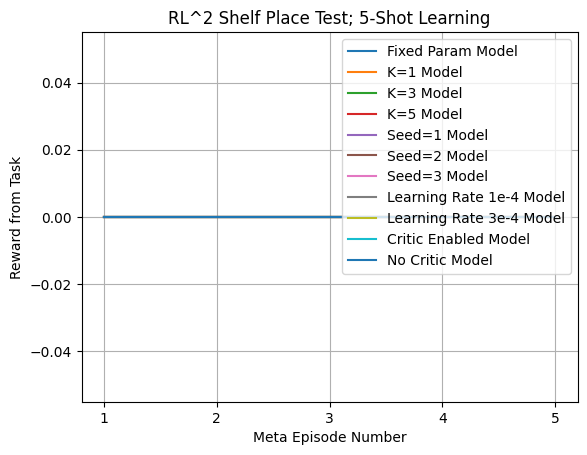

In [ ]:
shelf_rewards_list=run_test_task(model_list, shelf_env, shelf_place, k_shot=5)
plot(results_model_list, shelf_rewards_list, k=5, title="RL^2 Shelf Place Test; 5-Shot Learning")

| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 2630.60 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 2623.96 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(2532.2034), np.float32(2594.137), np.float32(2259.1912), np.float32(3103.667), np.float32(2630.599)]
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 580.54 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 590.47 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(591.8057), np.float32(585.9006), np.float32(593.5653), np.float32(600.51373), np.float32(580.54034)]
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 883.72 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 1131.77 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(1638.103), np.float32(771.1353), np.float32(1359.994), np.float32(1005.8988), np.float32(883.71906)]
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 948.48 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 958.03 | Success: 0
Steps per shot: [768, 768, 7

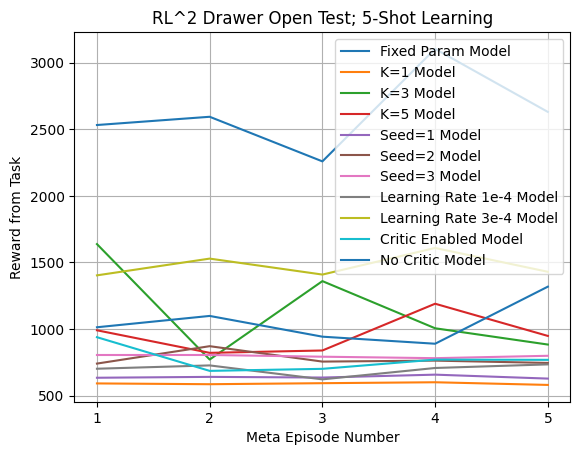

In [ ]:
drawer_rewards_list=run_test_task(model_list, drawer_env, drawer_task, k_shot=5)
plot(results_model_list, drawer_rewards_list, k=5, title="RL^2 Drawer Open Test; 5-Shot Learning")

| Final K_shot Task: SawyerLeverPullEnvV3 | Reward: 467.02 | 
Task: SawyerLeverPullEnvV3 | Mean reward: 421.43 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(399.54868), np.float32(383.75867), np.float32(431.7069), np.float32(425.09818), np.float32(467.0158)]
| Final K_shot Task: SawyerLeverPullEnvV3 | Reward: 204.80 | 
Task: SawyerLeverPullEnvV3 | Mean reward: 209.43 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(212.59303), np.float32(184.5383), np.float32(212.76324), np.float32(232.45535), np.float32(204.80124)]
| Final K_shot Task: SawyerLeverPullEnvV3 | Reward: 162.06 | 
Task: SawyerLeverPullEnvV3 | Mean reward: 168.85 | Success: 0
Steps per shot: [768, 768, 768, 768, 768]
[np.float32(203.13962), np.float32(142.53268), np.float32(189.17508), np.float32(147.35829), np.float32(162.06418)]
| Final K_shot Task: SawyerLeverPullEnvV3 | Reward: 303.24 | 
Task: SawyerLeverPullEnvV3 | Mean reward: 268.22 | Success: 0
Steps per shot: [768, 768, 768, 7

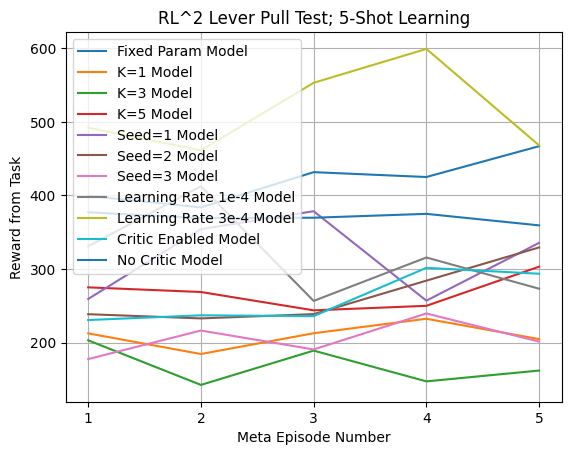

In [ ]:
lever_rewards_list=run_test_task(model_list, lever_env, lever_pull, k_shot=5)
plot(results_model_list, lever_rewards_list, k=5, title="RL^2 Lever Pull Test; 5-Shot Learning")

### Inner K in environment Test
For my K=[1, 3, 5] models should I initialize the env with the same K?

-Results don't seem to have changed much

In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/"

K=1
max_episode_steps=256

door_env = DummyVecEnv([lambda: make_env(door_close, K=K)])
door_env.training = False
door_env.norm_reward = False
k1_model= RecurrentPPO.load(save_path + "/ablations/K/k1_rl2_ml10"+".zip", env=door_env)

results_model_list=[]
results_rewards_list=[]
success_rate, rewards_door = run_k_shot(k1_model, drawer_env, drawer_task, k_shot=5)
results_model_list.append("K=1 Model")
results_rewards_list.append(rewards_door)


| Round 0  | Reward: 587.47 | 
| Round 1  | Reward: 597.71 | 
| Round 2  | Reward: 593.91 | 
| Round 3  | Reward: 596.33 | 
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 595.92 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 594.27 | Success: 0


In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/"

K=3
max_episode_steps=256

door_env = DummyVecEnv([lambda: make_env(door_close, K=K)])
door_env.training = False
door_env.norm_reward = False

results_model_list=[]
results_rewards_list=[]


k3_model= RecurrentPPO.load(save_path +"/ablations/K/k3_rl2_ml10"+ ".zip", env=door_env)

success_rate, rewards_door = run_k_shot(k3_model, drawer_env, drawer_task, k_shot=5)
results_model_list.append("K=3 Model")
results_rewards_list.append(rewards_door)



| Round 0  | Reward: 1124.72 | 
| Round 1  | Reward: 929.54 | 
| Round 2  | Reward: 852.64 | 
| Round 3  | Reward: 820.93 | 
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 1260.94 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 997.76 | Success: 0


In [ ]:
save_path = "/content/drive/Shared drives/CMPE260_group12/rl2_models/"

K=5
max_episode_steps=256

door_env = DummyVecEnv([lambda: make_env(door_close, K=K)])
door_env.training = False
door_env.norm_reward = False

results_model_list=[]
results_rewards_list=[]

k5_model= RecurrentPPO.load(save_path + "/ablations/K/k5_rl2_ml10"+".zip", env=door_env)

success_rate, rewards_door = run_k_shot(k5_model, drawer_env, drawer_task, k_shot=5)
results_model_list.append("K=5 Model")
results_rewards_list.append(rewards_door)

| Round 0  | Reward: 891.33 | 
| Round 1  | Reward: 1601.64 | 
| Round 2  | Reward: 1270.88 | 
| Round 3  | Reward: 1042.43 | 
| Final K_shot Task: SawyerDrawerOpenEnvV3 | Reward: 895.29 | 
Task: SawyerDrawerOpenEnvV3 | Mean reward: 1140.31 | Success: 0


### Tensorboards

In [ ]:
%load_ext tensorboard
%tensorboard --logdir "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/K"

In [ ]:
%tensorboard --logdir "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/lr"

In [ ]:
%tensorboard --logdir "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/seeds"

In [ ]:
%tensorboard --logdir "/content/drive/Shared drives/CMPE260_group12/rl2_models/ablations/critic"